In [1]:
import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
import dnnlib.util_v4 as util
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from plot_neural import *
from plot_sim_results import * 
import pandas as pd

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

In [2]:
colorgrad = "twilight"

# 1. Read Data

In [3]:
folder_data = 'data/mc_maze3'
dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
data_raw = dataset_samples['samples']
dset_samples = []
for ii in range(len(data_raw)):
    dset_samples.append(np.asarray(data_raw[ii], dtype=np.float64))

In [4]:
# corresponding meta data
train_meta = np.load(folder_data + "/meta_train.npy", allow_pickle=True).tolist()
trial_idx_use = np.array(train_meta['trial_info']['trial_version']) == 0
np.sum(trial_idx_use)

592

# 2. Behavior Data

In [5]:
trial_type_use = np.array(train_meta['trial_info']['trial_type'])[trial_idx_use]
indices = np.where(trial_idx_use)[0]

target_pos_sel = [train_meta['trial_info']['target_pos'][idx] for idx in indices]
target_pos_sel = np.array(target_pos_sel).squeeze(1).astype(np.float32)

hand_pos_sel = [train_meta['behavior']['hand_pos'][idx] for idx in indices]
cursor_pos_sel = [train_meta['behavior']['cursor_pos'][idx] for idx in indices]
eye_pos_sel = [train_meta['behavior']['eye_pos'][idx] for idx in indices]

# 3. Model Generations

4 models:

1. latent dim = 3, dynamic flow: lag = 5
2. latent dim = 3, dynamic flow: lag = 5, target location as covariate
3. latent dim = 3, dynamic flow: lag = 10
4. latent dim = 3, dynamic flow: lag = 10, target location as covariate

In [6]:
dt = 0.001

In [7]:
# # no clamp
# clamp_range = None

# # version 1: global clamp (results are similar)
# min_value = min(np.min(arr) for arr in dset_samples)
# max_value = max(np.max(arr) for arr in dset_samples)
# clamp_range = np.array([min_value, max_value]) # give some space

# version 2: clamp dim-by-dim (results are similar)
T_max = max(arr.shape[0] for arr in dset_samples)
padded_arrays = [np.pad(arr, ((0, T_max - arr.shape[0]), (0, 0)),
                        mode='constant', constant_values=np.nan) 
                 for arr in dset_samples]
stacked = np.stack(padded_arrays, axis=0)  # Shape [n_trial, T_max, dim]
eps_clamp = 1e-2

min_vals = np.nanmin(stacked, axis=(0, 1))  # Shape [dim]
max_vals = np.nanmax(stacked, axis=(0, 1))  # Shape [dim]

clamp_range = np.stack([min_vals, max_vals], axis=1)  # Shape [dim, 2]
clamp_range[:,0] = clamp_range[:,0] - eps_clamp
clamp_range[:,1] = clamp_range[:,1] + eps_clamp

## 3.1 dim3, lag5, noCov

In [8]:
folder_data = 'out/maze/dim3_lag5/data'
folder = 'out/maze/dim3_lag5/00000-maze_dim3_lag5-prr-uncond-regularFM-gpus1-batch256-fp32'
chk_pts = '/network-snapshot-500000.pkl'
dim_preserve = 3

dset_samples1, lag_samples1,\
flow_net1, dyn_net1, encoder1,\
d1, L1, loading1, traj_sim_tau1_1, traj_sim_tau0_1 =\
model_gen(folder_data, folder, chk_pts, dim_preserve, clamp_range, device, useCov = False)

100%|██████████████████████████████████████████| 94/94 [00:00<00:00, 170.54it/s]


project starting points to latent


100%|██████████████████████████████████████████| 94/94 [00:00<00:00, 189.90it/s]


In [9]:
lag = 5
traj_sim_tau1_comp_1 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau1_1[j])) for j in range(len(dset_samples))]
traj_sim_tau0_comp_1 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau0_1[j])) for j in range(len(dset_samples))]

## 3.2 dim3, lag5, location cov

In [10]:
folder_data = 'out/maze/dim3_lag5_cov/data'
folder = 'out/maze/dim3_lag5_cov/00000-maze_dim3_lag5-prr-uncond-regularFM-gpus1-batch256-fp32'
chk_pts = '/network-snapshot-500000.pkl'
dim_preserve = 3

dset_samples2, lag_samples2, covStat_samples2,\
flow_net2, dyn_net2, encoder2,\
d2, L2, loading2, traj_sim_tau1_2, traj_sim_tau0_2 =\
model_gen(folder_data, folder, chk_pts, dim_preserve, clamp_range, device, useCov = True)

100%|███████████████████████████████████████████| 94/94 [00:01<00:00, 91.83it/s]


project starting points to latent


100%|███████████████████████████████████████████| 94/94 [00:01<00:00, 92.03it/s]


In [11]:
lag = 5
traj_sim_tau1_comp_2 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau1_2[j])) for j in range(len(dset_samples))]
traj_sim_tau0_comp_2 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau0_2[j])) for j in range(len(dset_samples))]

## 3.3 dim3, lag10, noCov

In [12]:
folder_data = 'out/maze/dim3_lag10/data'
folder = 'out/maze/dim3_lag10/00000-maze_dim3_lag10-prr-uncond-regularFM-gpus1-batch256-fp32'
chk_pts = '/network-snapshot-500000.pkl' # '/network-snapshot-210739.pkl'
dim_preserve = 3

dset_samples3, lag_samples3,\
flow_net3, dyn_net3, encoder3,\
d3, L3, loading3, traj_sim_tau1_3, traj_sim_tau0_3 =\
model_gen(folder_data, folder, chk_pts, dim_preserve, clamp_range, device, useCov = False)

100%|██████████████████████████████████████████| 89/89 [00:00<00:00, 184.93it/s]


project starting points to latent


100%|██████████████████████████████████████████| 89/89 [00:00<00:00, 187.00it/s]


In [13]:
lag = 10
traj_sim_tau1_comp_3 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau1_3[j])) for j in range(len(dset_samples))]
traj_sim_tau0_comp_3 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau0_3[j])) for j in range(len(dset_samples))]

## 3.4 dim3, lag10, location cov

In [14]:
folder_data = 'out/maze/dim3_lag10_cov/data'
folder = 'out/maze/dim3_lag10_cov/00000-maze_dim3_lag10-prr-uncond-regularFM-gpus1-batch256-fp32'
chk_pts = '/network-snapshot-500000.pkl'

dset_samples4, lag_samples4, covStat_samples4,\
flow_net4, dyn_net4, encoder4,\
d4, L4, loading4, traj_sim_tau1_4, traj_sim_tau0_4 =\
model_gen(folder_data, folder, chk_pts, dim_preserve, clamp_range, device, useCov = True)

100%|███████████████████████████████████████████| 89/89 [00:00<00:00, 91.80it/s]


project starting points to latent


100%|███████████████████████████████████████████| 89/89 [00:00<00:00, 91.91it/s]


In [15]:
lag = 10
traj_sim_tau1_comp_4 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau1_4[j])) for j in range(len(dset_samples))]
traj_sim_tau0_comp_4 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau0_4[j])) for j in range(len(dset_samples))]

# 4. Check Fittings

## 4.1 MSE

Just a very rough numeric check for time series generation when $\tau = 1.0$ and $\tau = 0.0$.
Here, I show 2 MSEs:
1. Calculate MSE for each trial, and average these MSEs over trial (table)
2. Calculate MSE for each trial & dimension (neuron), and average these MSEs over trial (plot)

**It seems including location doesn't help a lot, but make things even more unstable. (maybe need smaller models for covariate version)**

In [16]:
plot_root = "plot/results"

In [17]:
# tau = 1.0
overall_mse_tau1_1, per_trial_tau1_1,\
overall_mse_dim_tau1_1, per_trial_dim_tau1_1 = list_mse_equal_weight(dset_samples, traj_sim_tau1_comp_1)
overall_mse_tau1_2, per_trial_tau1_2,\
overall_mse_dim_tau1_2, per_trial_dim_tau1_2 = list_mse_equal_weight(dset_samples, traj_sim_tau1_comp_2)
overall_mse_tau1_3, per_trial_tau1_3,\
overall_mse_dim_tau1_3, per_trial_dim_tau1_3 = list_mse_equal_weight(dset_samples, traj_sim_tau1_comp_3)
overall_mse_tau1_4, per_trial_tau1_4,\
overall_mse_dim_tau1_4, per_trial_dim_tau1_4 = list_mse_equal_weight(dset_samples, traj_sim_tau1_comp_4)

# tau = 0.0
overall_mse_tau0_1, per_trial_tau0_1,\
overall_mse_dim_tau0_1, per_trial_dim_tau0_1 = list_mse_equal_weight(dset_samples, traj_sim_tau0_comp_1)
overall_mse_tau0_2, per_trial_tau0_2,\
overall_mse_dim_tau0_2, per_trial_dim_tau0_2 = list_mse_equal_weight(dset_samples, traj_sim_tau0_comp_2)
overall_mse_tau0_3, per_trial_tau0_3,\
overall_mse_dim_tau0_3, per_trial_dim_tau0_3 = list_mse_equal_weight(dset_samples, traj_sim_tau0_comp_3)
overall_mse_tau0_4, per_trial_tau0_4,\
overall_mse_dim_tau0_4, per_trial_dim_tau0_4 = list_mse_equal_weight(dset_samples, traj_sim_tau0_comp_4)

In [18]:
data = {
    'model': ['dim 3, lag 5', 'dim 3, lag 5, location', 'dim 3, lag 10', 'dim 3, lag 10, location'],
    'tau = 0.0': [overall_mse_tau0_1, overall_mse_tau0_2, overall_mse_tau0_3, overall_mse_tau0_4],
    'tau = 1.0': [overall_mse_tau1_1, overall_mse_tau1_2, overall_mse_tau1_3, overall_mse_tau1_4]
}

df = pd.DataFrame(data)
df.style.set_caption("MSE over trial").format(precision=4)

,model,tau = 0.0,tau = 1.0
0,"dim 3, lag 5",0.0008,0.0007
1,"dim 3, lag 5, location",0.0016,0.0005
2,"dim 3, lag 10",0.0005,0.0004
3,"dim 3, lag 10, location",0.0006,0.0003


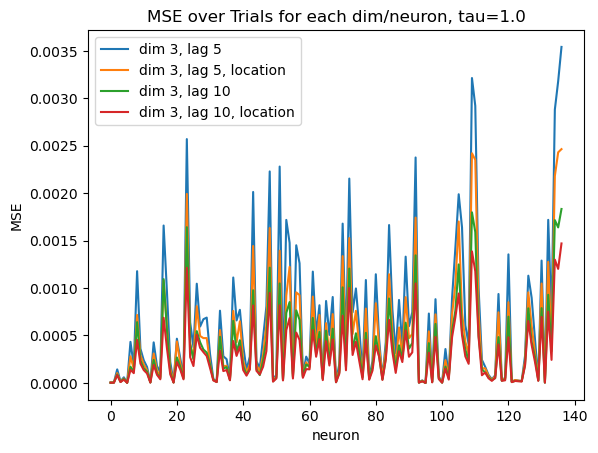

In [19]:
plt.plot(overall_mse_dim_tau1_1, label='dim 3, lag 5')
plt.plot(overall_mse_dim_tau1_2, label='dim 3, lag 5, location')
plt.plot(overall_mse_dim_tau1_3, label='dim 3, lag 10')
plt.plot(overall_mse_dim_tau1_4, label='dim 3, lag 10, location')
plt.ylabel('MSE')
plt.xlabel('neuron')
plt.title('MSE over Trials for each dim/neuron, tau=1.0')
plt.legend()
plt.savefig(plot_root + "/1_mse_tau1.png")

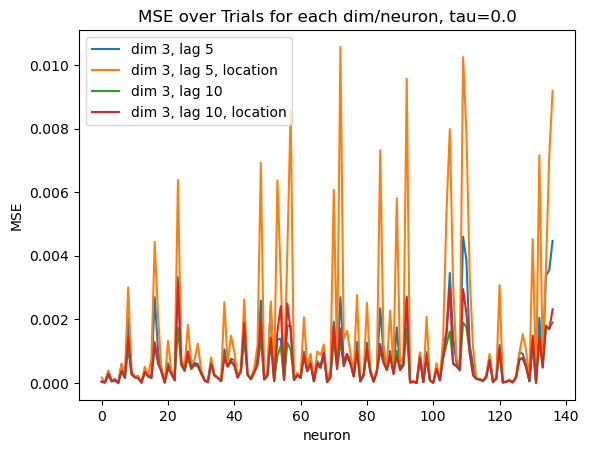

In [20]:
plt.plot(overall_mse_dim_tau0_1, label='dim 3, lag 5')
plt.plot(overall_mse_dim_tau0_2, label='dim 3, lag 5, location')
plt.plot(overall_mse_dim_tau0_3, label='dim 3, lag 10')
plt.plot(overall_mse_dim_tau0_4, label='dim 3, lag 10, location')
plt.ylabel('MSE')
plt.xlabel('neuron')
plt.title('MSE over Trials for each dim/neuron, tau=0.0')
plt.legend()
plt.savefig(plot_root + "/2_mse_tau0.png")

# 4.2 latent

Here, I show dim_to_keep = 3, lag = 10, no covariate version

### 4.2.1 check d and loading

Seems the latent should be 1D (the 2nd one)

In [21]:
plot_dir = plot_root + "/dim3_lag10"
d_use = d3
loading_use = loading3
traj_sim_tau0_use = traj_sim_tau0_3
encoder_use = encoder3
dset_samples_use = dset_samples3
flow_net_use = flow_net3
dim_to_plot = 1 # np.arange(dim_preserve)

In [22]:
torch.diag(d_use)[0:10]

tensor([1.0082e-13, 6.0679e-11, 7.5896e-13, 9.9540e-16, 1.5536e-16, 2.3862e-19,
        7.9226e-17, 6.0119e-17, 9.9640e-16, 9.9527e-16], device='cuda:0')

Loading = $L\sqrt{D}$

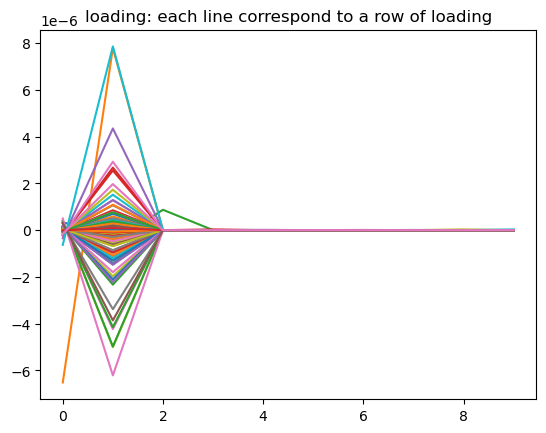

In [23]:
plt.plot(loading_use[:,0:10].detach().cpu().numpy().T);
plt.title('loading: each line correspond to a row of loading')
plt.savefig(plot_dir + "/1_loading.png")

### 4.2.2 simulated latent trajectories

1. use compression flow to flow starting data to dimension,
2. and then use dynamic flow at $\tau = 0.0$ to rollover.

In [24]:
theta_deg = get_theta_deg(target_pos_sel)

In [25]:
mu_traj_sim = latent_mu(traj_sim_tau0_use, encoder_use, dim_preserve, device)
mu_traj_sim_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]

loc_unique, _, mean_traj_sim, _ = mean_traj_by_labels(np.array(mu_traj_sim_np), target_pos_sel)
theta_deg_unique = get_theta_deg(loc_unique)
mean_traj_list_sim = list(mean_traj_sim)

100%|███████████████████████████████████████| 592/592 [00:00<00:00, 3822.57it/s]


/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt/plot_sim_results.py:248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.18 if use_labels else 0.02, 0.98, 0.98])


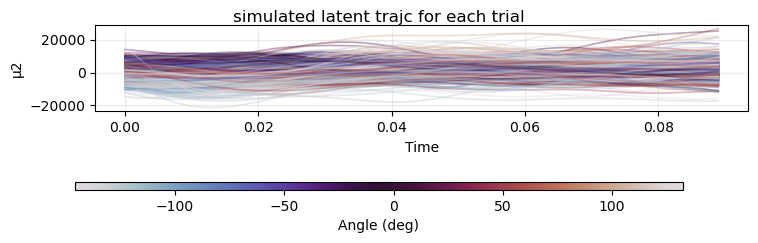

In [26]:
plot_latent_time_series(mu_traj_sim_np, alpha = 0.4, dims=dim_to_plot, 
                        dt=dt, labels=theta_deg, cont_cmap=colorgrad)
plt.suptitle('simulated latent trajc for each trial')
plt.savefig(plot_dir + "/2_sim_traj.png")

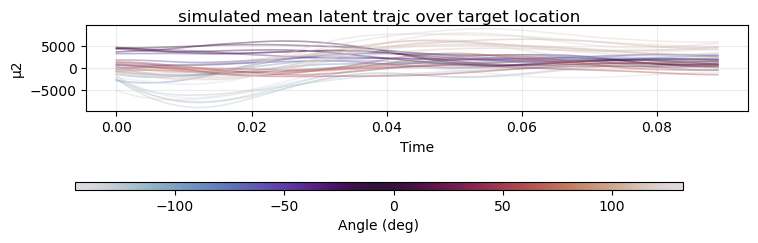

In [27]:
plot_latent_time_series(mean_traj_list_sim, alpha = 0.4, dims=dim_to_plot, 
                        dt=dt, labels=theta_deg_unique)
plt.suptitle('simulated mean latent trajc over target location')
plt.savefig(plot_dir + "/3_sim_traj_mean.png")

### 4.2.3 flowed latent trajectories

Use compression flow, to compress data point by point

In [28]:
latent_traj_list = proj_to_latent(dset_samples_use, flow_net_use, 0.0, device)
mu_traj_flow = latent_mu(latent_traj_list, encoder_use, dim_preserve, device)
mu_traj_flow_np = [mu_traj_flow[j].cpu().numpy() for j in range(len(mu_traj_flow))]

loc_unique, _, mean_traj_flow, _ = mean_traj_by_labels(np.array(mu_traj_flow_np), target_pos_sel)
theta_deg_unique = get_theta_deg(loc_unique)
mean_traj_list_flow = list(mean_traj_flow)

100%|███████████████████████████████████████| 592/592 [00:00<00:00, 3849.14it/s]


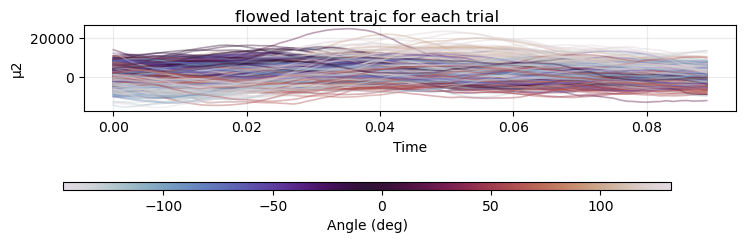

In [29]:
plot_latent_time_series(mu_traj_flow_np, alpha = 0.4, dims=dim_to_plot, 
                        dt=dt, labels=theta_deg, cont_cmap=colorgrad)
plt.suptitle('flowed latent trajc for each trial')
plt.savefig(plot_dir + "/4_flow_traj.png")

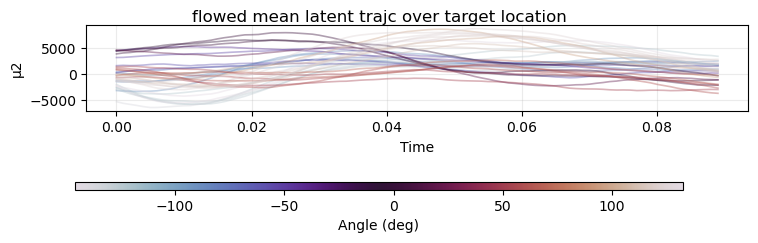

In [30]:
plot_latent_time_series(mean_traj_list_flow, alpha = 0.4, dims=dim_to_plot, 
                        dt=dt, labels=theta_deg_unique)
plt.suptitle('flowed mean latent trajc over target location')
plt.savefig(plot_dir + "/5_flow_traj_mean.png")

# appendix...

Well, although 3-D latent doesn't make sense, if we really want to check it, it is here.

It is still using the model shown above

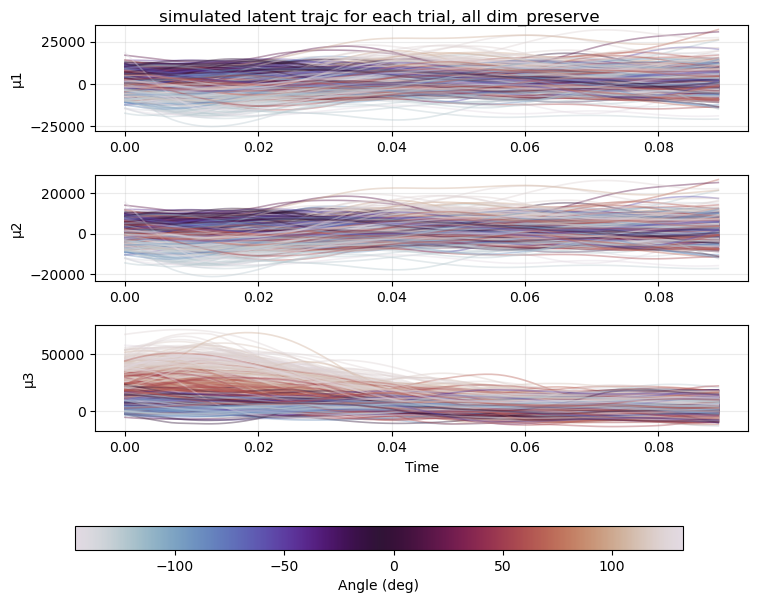

In [31]:
plot_latent_time_series(mu_traj_sim_np, alpha = 0.4, dims=np.arange(dim_preserve), 
                        dt=dt, labels=theta_deg, cont_cmap=colorgrad)
plt.suptitle('simulated latent trajc for each trial, all dim_preserve')
plt.savefig(plot_dir + "/6_sim_traj_all.png")

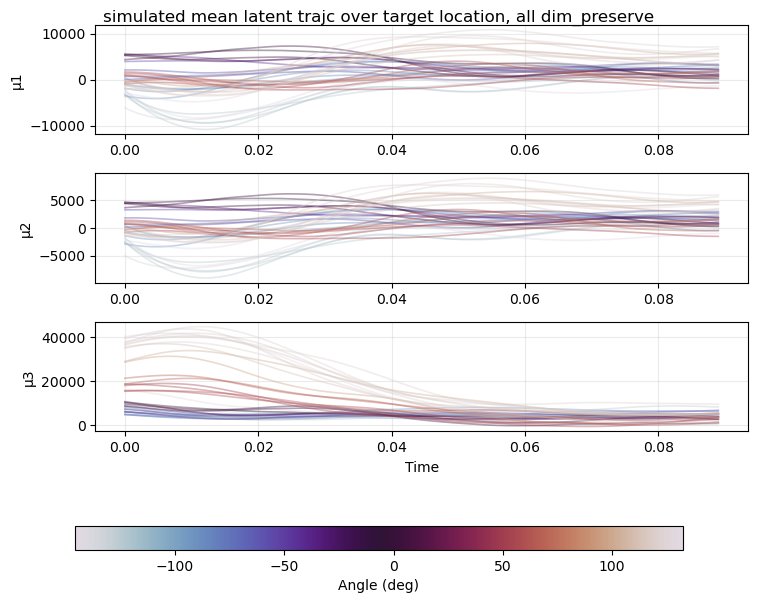

In [32]:
plot_latent_time_series(mean_traj_list_sim, alpha = 0.4, dims=np.arange(dim_preserve), 
                        dt=dt, labels=theta_deg_unique)
plt.suptitle('simulated mean latent trajc over target location, all dim_preserve')
plt.savefig(plot_dir + "/7_sim_traj_all_mean.png")

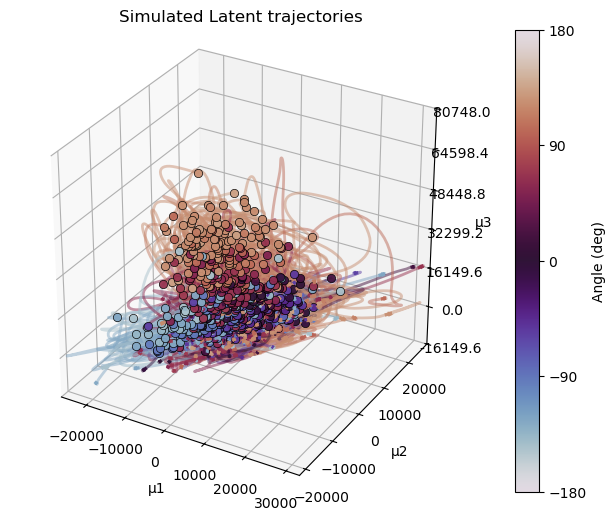

In [33]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_sim_np,
    labels=theta_deg,
    trial_indices=np.arange(len(mu_traj_sim_np)), 
    dims=(0,1,2),
    title="Simulated Latent trajectories",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    circmap = colorgrad,
    elev_azim = None, # (20,45)
)
plt.savefig(plot_dir + "/8_sim_traj_all_3d.png")

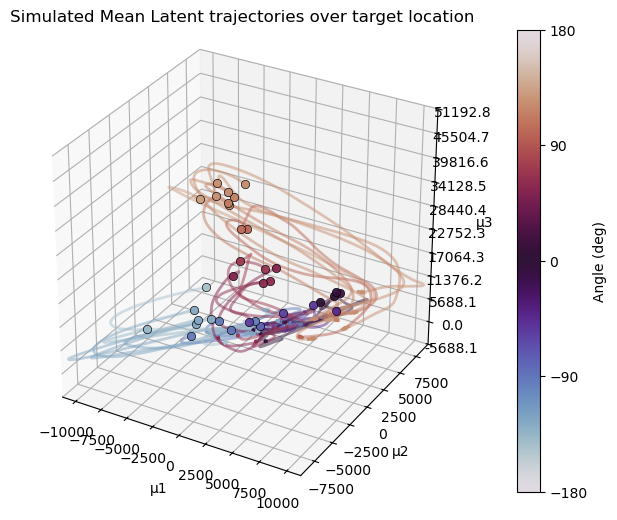

In [34]:
plot_mu_trajectories_gradient_steps_3d(
    mean_traj_list_sim,
    labels=theta_deg_unique,
    trial_indices=np.arange(len(mean_traj_list_sim)), 
    dims=(0,1,2),
    title="Simulated Mean Latent trajectories over target location",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    circmap = colorgrad,
    elev_azim = None, # (20,45)
)
plt.savefig(plot_dir + "/9_sim_traj_all_3d_mean.png")

/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt/plot_sim_results.py:248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.18 if use_labels else 0.02, 0.98, 0.98])


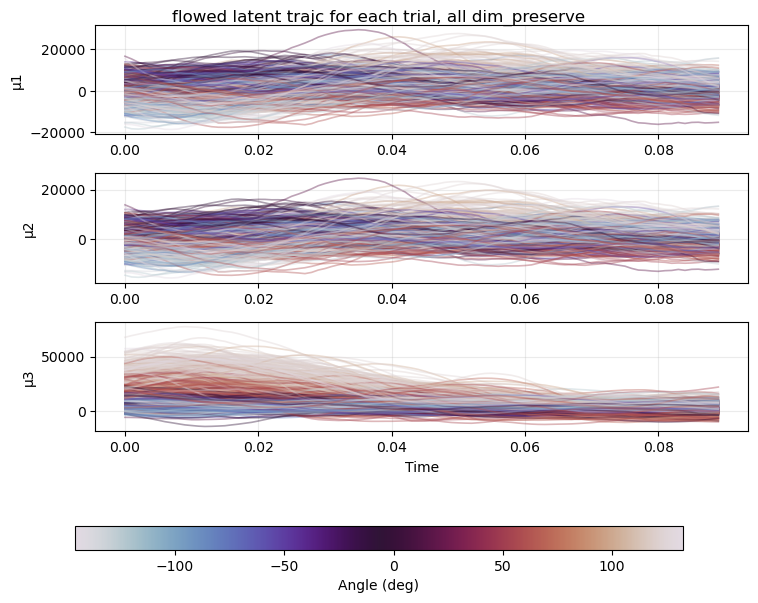

In [35]:
plot_latent_time_series(mu_traj_flow_np, alpha = 0.4, dims=np.arange(dim_preserve), 
                        dt=dt, labels=theta_deg, cont_cmap=colorgrad)
plt.suptitle('flowed latent trajc for each trial, all dim_preserve')
plt.savefig(plot_dir + "/10_flow_traj_all.png")

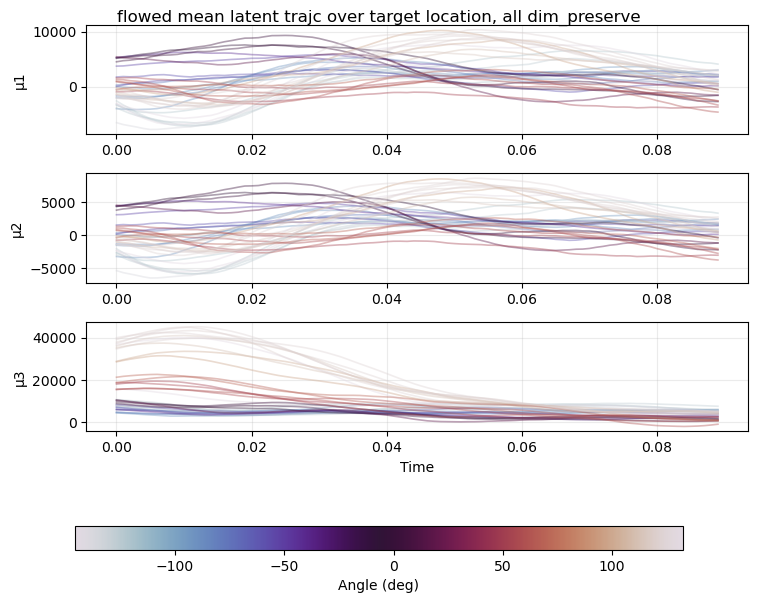

In [36]:
plot_latent_time_series(mean_traj_list_flow, alpha = 0.4, dims=np.arange(dim_preserve), 
                        dt=dt, labels=theta_deg_unique)
plt.suptitle('flowed mean latent trajc over target location, all dim_preserve')
plt.savefig(plot_dir + "/11_flow_traj_all_mean.png")

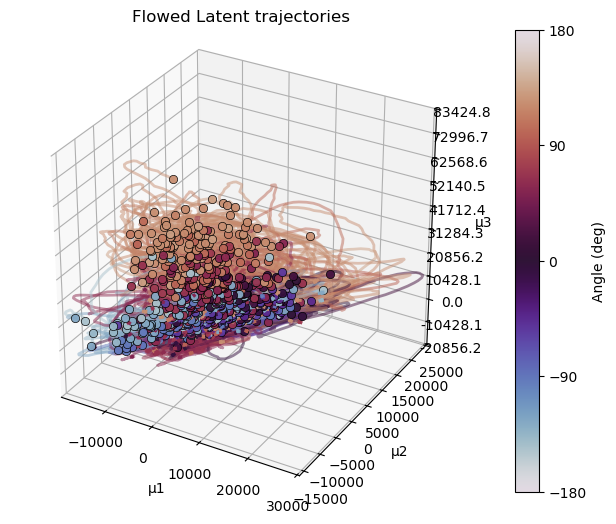

In [37]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_flow_np,
    labels=theta_deg,
    trial_indices=np.arange(len(mu_traj_flow_np)), 
    dims=(0,1,2),
    title="Flowed Latent trajectories",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    circmap = colorgrad,
    elev_azim = None, # (20,45)
)
plt.savefig(plot_dir + "/12_flow_traj_all_3d.png")

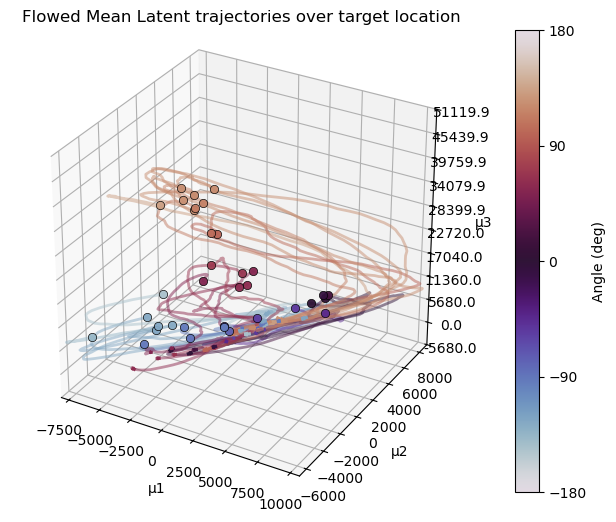

In [38]:
plot_mu_trajectories_gradient_steps_3d(
    mean_traj_list_flow,
    labels=theta_deg_unique,
    trial_indices=np.arange(len(mean_traj_list_flow)), 
    dims=(0,1,2),
    title="Flowed Mean Latent trajectories over target location",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    circmap = colorgrad,
    elev_azim = None, # (20,45)
)
plt.savefig(plot_dir + "/13_flow_traj_all_3d_mean.png")